## Week 12 Practice

In [48]:
import torch 
import torchvision
from torchvision.transforms import ToTensor

Week 12-2 RNN

In [ ]:
# class SimpleRNNCell(nn.module): 
#     def __init__(self, input_size, hidden_size, output_size): 
#         super().__init__()

#         # Dfine the weights as parameters so they are tracked by PyTorch
#         self.Wxh = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)  # Input to hidden
#         self.Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01) # Hidden to hidden
#         self.Why = nn.Parameter(torch.randn(output_size, hidden_size) * 0.01)  # Hidden to output
#         self.hidden_size = hidden_size
#         self.h = None 

#     def forward(self, x): 
#         if self.h is None: 
#             self.h = torch.zeros(x.size(0), self.hidden_size)

#         # Compute the new hidden state
#         self.h = torch.tanh(torch.matmul(x, self.Wxh.t()) + torch.matmul(self.h, self.Whh.t()))

#         # Compute the output
#         y = torch.matmul(self.h, self.Why.t())
#         return y

# class RNNModel(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size): 
#         super().__init__()
#         self.rnn = SimpleRNNCell(input_size, hidden_size, output_size)
#         self.fc = nn.Linear(hidden_size, output_size)
    
#     def forward(self, x): 
#         out = self.rnn(x)
#         out = self.fc(out)
#         return out

Week 12-2 Live Demo

In [49]:
import torch 
from torch import nn

In [50]:
text = '''During the band's North American leg in autumn 2008, after a show on September 6, 2008, the vocalist M. Shadows had difficulties singing, and flew to see his doctor, cancelling the Baltimore show the next day. The whole co-headlining tour with Buckcherry was then cancelled because of Shadows' case of vocal fatigue. The band resumed the tour after Shadows took some rest, with a short Japanese leg starting on October 15, 2008, and then on November 4, 2008, the band rescheduled its cancelled North American leg and played through November and December a co-headlining tour with Buckcherry and the support acts Shinedown and Saving Abel, in place of the cancelled tour.'''

In [51]:
text

"During the band's North American leg in autumn 2008, after a show on September 6, 2008, the vocalist M. Shadows had difficulties singing, and flew to see his doctor, cancelling the Baltimore show the next day. The whole co-headlining tour with Buckcherry was then cancelled because of Shadows' case of vocal fatigue. The band resumed the tour after Shadows took some rest, with a short Japanese leg starting on October 15, 2008, and then on November 4, 2008, the band rescheduled its cancelled North American leg and played through November and December a co-headlining tour with Buckcherry and the support acts Shinedown and Saving Abel, in place of the cancelled tour."

In [52]:
import re 
len(set(re.sub(r'[^a-zA-Z\s]', '', text.strip().lower()).split()))

63

In [53]:
words_normalized = re.sub(r'[^a-zA-Z\s]', '', text.strip().lower())

In [54]:
from torch.utils.data import Dataset, DataLoader 

class TextDataset(Dataset): 
    def __init__(self, text, sequence_length): 
        self.text = text 
        self.sequence_length = sequence_length

        words = text.split() 
        self.vocab = ['<PAD>'] + list(set(words))
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = dict(map(reversed, self.word_to_idx.items()))

        self.sequences = []
        self.targets = []

        for i in range(len(words) - sequence_length):
            seq = words[i:i + sequence_length]
            target = words[i + sequence_length]
            seq_idx = [self.word_to_idx[word] for word in seq]
            target_idx = self.word_to_idx[target]
            self.sequences.append(seq_idx)
            self.targets.append(target_idx)

    def __len__(self): 
        return len(self.sequences)
    
    def __getitem__(self, index):
        return (torch.tensor(self.sequences[index]), 
                torch.tensor(self.targets[index]))
    
    def vocab_size(self):
        return len(self.vocab)

ds = TextDataset(words_normalized, sequence_length=5)

In [55]:
ds.sequences[0], ds.targets[0]

([53, 11, 36, 38, 41], 12)

In [56]:
[ds.idx_to_word[idx] for idx in ds.sequences[0]], ds.idx_to_word[ds.targets[0]]

(['during', 'the', 'bands', 'north', 'american'], 'leg')

In [57]:
ee = nn.Embedding(ds.vocab_size(), 16)
ee(ds[0][0])  # Example embedding lookup

tensor([[-0.8147,  0.8241,  2.3371, -0.8235, -0.9105, -0.9561,  0.3667, -1.0931,
         -0.9358, -1.0203, -0.4781,  1.0496,  1.2416, -1.1473, -1.4447,  2.0865],
        [-0.9910, -0.0395,  0.3011, -0.8123,  0.5282,  0.6727, -0.3383, -0.0215,
          0.7585, -0.4480,  0.0809, -1.0888, -0.7481, -0.0974,  0.3238, -0.3562],
        [ 1.1929,  0.4015, -0.3017, -0.6565, -1.5092, -0.3870,  1.5030,  0.0655,
          1.1175, -1.3226, -0.3287, -0.9763,  0.9114,  0.5465, -0.1614, -2.0288],
        [-0.3680, -2.1094, -0.2323, -0.5724,  1.3891, -1.2076, -1.8899, -0.9771,
          0.6430, -0.5220,  0.4934, -1.8545,  0.7424, -1.4613,  0.1941, -0.3489],
        [-0.1763, -0.1169,  1.0353,  1.0230,  0.1264, -0.4658,  0.8730,  0.9716,
         -1.0156,  0.4295, -1.0822,  1.3255, -0.4823, -2.1384,  0.7267, -0.3772]],
       grad_fn=<EmbeddingBackward0>)

In [66]:
from torch import nn 

class SimpleRNN(nn.Module): 
    def __init__(self, vocab_size, embedding_dim, hidden_dim): 
        super().__init__()
        self.hidden_dim = hidden_dim 
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h): 
        embeds = self.embedding(x)
        out, h_prime = self.rnn(embeds, h)
        out = self.fc(out) 
        return out, h_prime 
    
    def init_hidden(self, batch_size): 
        return torch.zeros(1, batch_size, self.hidden_dim)
    

In [67]:
ce_loss = nn.CrossEntropyLoss()

def loss_fn(X, y, model): 
    batch_size = X.shape[0]
    sequence_length = X.shape[1]
    h = model.init_hidden(batch_size)
    for i in range(sequence_length): 
        out, h = model(X[:, i], h)
    return ce_loss(out, y)

In [68]:
model = SimpleRNN(ds.vocab_size(), embedding_dim=16, hidden_dim=16)

X, y = ds[0:5]
X
loss_fn(X, y, model)


RuntimeError: For unbatched 2-D input, hx should also be 2-D but got 3-D tensor

In [189]:
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=ToTensor())
test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=ToTensor())

9

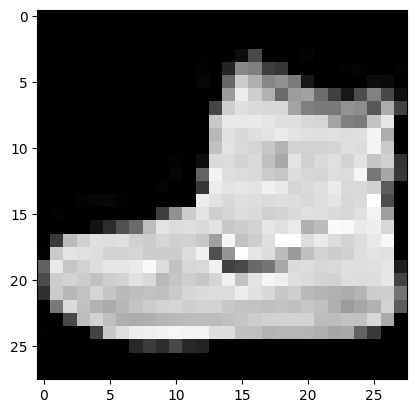

In [190]:
import matplotlib.pyplot as plt
X, y = train_data[0]
plt.imshow(X[0], cmap='gray')
y

In [191]:
labels_map = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

In [192]:
from torch import nn 

class Perceptron(nn.Module): 
    def __init__(self): 
        super().__init__()
        self.stack = nn.Sequential(
            nn.Flatten(), # flatten 28x28 image to 784 vector
            nn.Linear(28 * 28, 1), 
            nn.Sigmoid() # activation function; prob in [0,1]
        )

    def forward(self, x): 
        return self.stack(x)

In [193]:
model = Perceptron()
model

Perceptron(
  (stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=1, bias=True)
    (2): Sigmoid()
  )
)

In [194]:
model(X)

tensor([[0.5649]], grad_fn=<SigmoidBackward0>)

In [195]:
# for name, param in model.named_parameters():
#     print(f"{name}: {param}")

In [196]:
logits = torch.Tensor([1., 2., 3.])
e = torch.exp(logits)
e / e.sum()

tensor([0.0900, 0.2447, 0.6652])

In [197]:
torch.softmax(logits, dim=0)

tensor([0.0900, 0.2447, 0.6652])

In [198]:
class Perceptron(nn.Module): 
    def __init__(self): 
        super().__init__()
        self.stack = nn.Sequential(
            nn.Flatten(), # flatten 28x28 image to 784 vector
            nn.Linear(28 * 28, 10), 
            # nn.Sigmoid
            nn.Softmax(-1)
        )

    def forward(self, x): 
        return self.stack(x)

In [ ]:
# # exploring overfitting 
# class Perceptron(nn.Module): 
#     def __init__(self): 
#         super().__init__()
#         self.stack = nn.Sequential(
#             nn.Flatten(), # flatten 28x28 image to 784 vector
#             nn.Linear(28 * 28, 256), 
#             nn.ReLU(), 
#             nn.Linear(256, 128),
#             nn.ReLU(), 
#             nn.Linear(128, 10),
#             nn.Softmax(-1)
#         )

#     def forward(self, x): 
#         return self.stack(x)

In [200]:
model = Perceptron()
model

Perceptron(
  (stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
    (6): Softmax(dim=-1)
  )
)

In [201]:
print(model(X))

# # example case if output dim is 1
# v = torch.Tensor([3]) 
# e = torch.exp(v)
# e / e.sum()

tensor([[0.1063, 0.0964, 0.1172, 0.1000, 0.0974, 0.0934, 0.0944, 0.0980, 0.0967,
         0.1003]], grad_fn=<SoftmaxBackward0>)


In [202]:
y_hat = model(X)
print(y_hat); print(y); print(y_hat.sum())

tensor([[0.1063, 0.0964, 0.1172, 0.1000, 0.0974, 0.0934, 0.0944, 0.0980, 0.0967,
         0.1003]], grad_fn=<SoftmaxBackward0>)
9
tensor(1.0000, grad_fn=<SumBackward0>)


In [203]:
torch.eye(10)[y]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

### DataLoaders

In [204]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size = 64)
test_dataloader = DataLoader(test_data, batch_size = 64)

In [205]:
Xs, ys = next(iter(train_dataloader))
Xs.shape # first dim is batch size 

torch.Size([64, 1, 28, 28])

tensor(9)

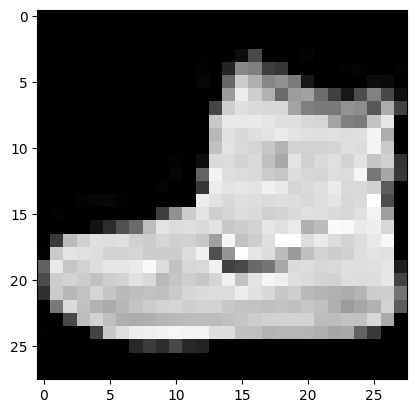

In [206]:
plt.imshow(Xs[0][0], cmap='gray')
ys[0]

tensor(5)

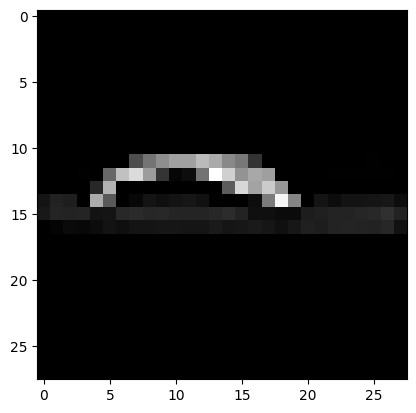

In [207]:
plt.imshow(Xs[63][0], cmap='gray')
ys[63]

In [208]:
model(Xs).shape

torch.Size([64, 10])

In [209]:
loss_fn = nn.CrossEntropyLoss()

In [210]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # compute prediction and loss 
        y_hat = model(X)
        loss = loss_fn(y_hat, y)

        # backpropagation (gradient descent)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0: 
            print(f"loss = {loss.item()} batch = {batch}")

In [211]:
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3) # default learning rate
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [212]:
y_hats = model(Xs)
y_hats[0]

tensor([0.1063, 0.0964, 0.1172, 0.1000, 0.0974, 0.0934, 0.0944, 0.0980, 0.0967,
        0.1003], grad_fn=<SelectBackward0>)

In [213]:
train_loop(train_dataloader, model, loss_fn, optimizer) #bette and better with more runtime; overfitting risk 

loss = 2.302802801132202 batch = 0
loss = 2.3023929595947266 batch = 100
loss = 2.3028063774108887 batch = 200
loss = 2.3025622367858887 batch = 300
loss = 2.3025217056274414 batch = 400
loss = 2.300952434539795 batch = 500
loss = 2.3014540672302246 batch = 600
loss = 2.300163984298706 batch = 700
loss = 2.3026750087738037 batch = 800
loss = 2.3013927936553955 batch = 900


In [214]:
y_hats = model(Xs)
y_hats[0]

tensor([0.1050, 0.0962, 0.1184, 0.0991, 0.0979, 0.0919, 0.0945, 0.0976, 0.0977,
        0.1017], grad_fn=<SelectBackward0>)

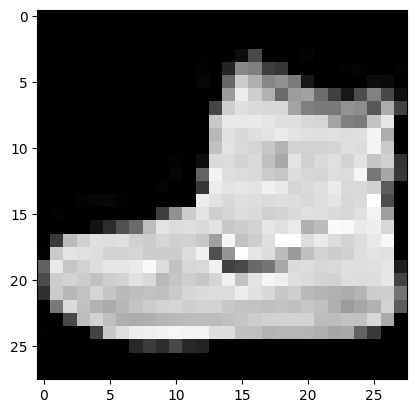

In [180]:
plt.imshow(Xs[0,0], cmap='gray')

In [181]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [182]:
def test_loop(dataloader, model, loss_fn): 
    model.eval()
    test_loss = 0.
    with torch.no_grad(): 
        for X, y in dataloader: 
            y_hat = model(X)
            test_loss += loss_fn(y_hat, y).item()
    
    test_loss /= len(dataloader)
    print(f"Test Loss: {test_loss}")
    

In [183]:
test_loop(test_dataloader, model, loss_fn)

Test Loss: 2.2736794887834293


In [184]:
# for t in range(5):
#     print(f"\nepoch {t}")
#     train_loop(train_dataloader, model, loss_fn, optimizer)
#     test_loop(test_dataloader, model, loss_fn)


epoch 0
loss = 2.28035306930542 batch = 0
loss = 2.280996084213257 batch = 100
loss = 2.2584166526794434 batch = 200
loss = 2.265836477279663 batch = 300
loss = 2.259477376937866 batch = 400
loss = 2.231827735900879 batch = 500
loss = 2.2547805309295654 batch = 600
loss = 2.227647066116333 batch = 700
loss = 2.254142999649048 batch = 800
loss = 2.2230560779571533 batch = 900
Test Loss: 2.2313696654738893

epoch 1
loss = 2.2443935871124268 batch = 0
loss = 2.2430367469787598 batch = 100
loss = 2.2044289112091064 batch = 200
loss = 2.2244231700897217 batch = 300
loss = 2.1966686248779297 batch = 400
loss = 2.17230224609375 batch = 500
loss = 2.2074546813964844 batch = 600
loss = 2.1712515354156494 batch = 700
loss = 2.216453790664673 batch = 800
loss = 2.1693220138549805 batch = 900
Test Loss: 2.182633820612719

epoch 2
loss = 2.20944881439209 batch = 0
loss = 2.2069759368896484 batch = 100
loss = 2.15619158744812 batch = 200
loss = 2.1750683784484863 batch = 300
loss = 2.14237594604492

KeyboardInterrupt: 